#**Analiza zbioru danych dotyczących wynajmu lokali przez platformę Airbnb w Nashville, Tennese, Stany Zjednoczone**

##1. Import bibliotek:

In [ ]:
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency

import statsmodels.formula.api as smf
import scipy.stats as stats

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##2. Ładowanie danych:



In [ ]:
url = '/content/drive/MyDrive/PRBD/Zadanie PRBD/listings.csv.gz'

df = pd.read_csv(url, compression='gzip', header=0, sep=',', encoding='utf-8', low_memory=False)

##3. Analiza rozmiaru zbioru danych:

In [ ]:
#liczba wierszy i kolumn
rows, columns = df.shape
print("Liczba obserwacji (wierszy): ", rows)
print("Liczba zmiennych (kolumn): ", columns)

Liczba obserwacji (wierszy):  9443
Liczba zmiennych (kolumn):  79


In [ ]:
#pomiar czasu
start_time = time.time()

#'include='all'' uwzględnia wszystkie typy danych w wyniku
description = df.describe(include='all')

end_time = time.time()
elapsed_time  = end_time - start_time

print("Szacowany czas:", round(elapsed_time, 2), "sekund\n")

Szacowany czas: 0.28 sekund



##4. Próbka danych:

In [ ]:
#Pierwsze 5 wierszy
print("Pierwsze 5 wierszy: ")
display(df.head())

Pierwsze 5 wierszy: 


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,days_since_first_review,days_since_last_review
0,6422,https://www.airbnb.com/rooms/6422,20250923202825,2025-09-23,city scrape,Nashville Charm,30 day plus rental - book for one month and th...,Historic East Nashville is home to many new an...,https://a0.muscache.com/pictures/miso/Hosting-...,12172,...,0.484943,0.698039,False,-0.554613,-0.544663,-0.075719,-0.049413,0.559762,4.981724,7.165818
1,39870,https://www.airbnb.com/rooms/39870,20250923202825,2025-09-24,city scrape,Close to Vanderbilt 2,"Since I am older, I need for guests to be vacc...","The house is in a safe, quiet, ""college"" neig...",https://a0.muscache.com/pictures/miso/Hosting-...,171184,...,0.519660,0.494259,False,-0.554613,-0.544663,-0.075719,-0.049413,1.383282,2.177841,-0.370363
2,72906,https://www.airbnb.com/rooms/72906,20250923202825,2025-09-23,city scrape,Vandy/Belmont/10 mins to Broadway - Sunny 800 ...,Entire private top floor of my home with share...,Historic Belmont-Hillsboro neighborhood. Walk-...,https://a0.muscache.com/pictures/1777db4f-d0a6...,176117,...,0.658526,0.426332,False,-0.554613,-0.524086,-0.228044,-0.049413,1.020933,4.180615,-0.388989
3,258817,https://www.airbnb.com/rooms/258817,20250923202825,2025-09-23,city scrape,"ButterflyRoom-queen room, private bath",Morningstar House! Extended stay - 3+ months- ...,"I'm very near the Percy Priest Lake, natural ...",https://a0.muscache.com/pictures/eef19bc4-2743...,22296,...,-0.139954,-0.151046,False,-0.411962,-0.544663,0.838231,20.237718,-0.576696,3.987100,1.972819
4,289242,https://www.airbnb.com/rooms/289242,20250923202825,2025-09-24,city scrape,"MorningstarHouse, monthly room-",Morningstar House! Extended stay - price reduc...,The Morningstar House is in a quiet cul-de-sac...,https://a0.muscache.com/pictures/40a7ab72-20f7...,22296,...,-1.077301,-0.286900,False,-0.411962,-0.544663,0.838231,20.237718,-0.630225,3.971494,8.719248


In [ ]:
#Ostatnie 5 wierszy
print("Ostatnie 5 wierszy: ")
display(df.tail())

Ostatnie 5 wierszy: 


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,days_since_first_review,days_since_last_review
9438,1514040723537094108,https://www.airbnb.com/rooms/1514040723537094108,20250923202825,2025-09-24,city scrape,Hyve - Neon Nights - Pool & Gym - Walk to Broa...,"Step into Neon Lights, where city buzz meets c...",SOBRO,https://a0.muscache.com/pictures/prohost-api/H...,20772148,...,0.276644,0.188588,True,2.155758,2.212671,-0.228044,-0.049413,-0.815517,-0.263982,-0.310759
9439,1514048464546854587,https://www.airbnb.com/rooms/1514048464546854587,20250923202825,2025-09-24,city scrape,"Music Row Luxe Retreat: 4-Bed, 4-Bath Oasis","COMING SOON! Luxe 4-bed, 4-bath Music Row retr...",Brak danych,https://a0.muscache.com/pictures/hosting/Hosti...,449210171,...,0.276644,0.188588,True,-0.310068,-0.277160,-0.228044,-0.049413,-0.815517,-0.263982,-0.310759
9440,1514756193703294117,https://www.airbnb.com/rooms/1514756193703294117,20250923202825,2025-09-24,city scrape,The Magnolia #11 by AvantStay | 5 Mins to Down...,- Within 5 mins from DT Nashville<br />- Kid-f...,"Local Attractions: Honky Tonk, The Ryman Theat...",https://a0.muscache.com/pictures/prohost-api/H...,338667310,...,0.276644,0.188588,True,4.091738,4.167497,-0.228044,-0.049413,-0.815517,-0.263982,-0.310759
9441,1514858056379581821,https://www.airbnb.com/rooms/1514858056379581821,20250923202825,2025-09-24,city scrape,Broadway Bar | Parking + Pool + Gym + Court Yard!,🤠 Honky-Tonk Hideout<br /><br />🎸 Free Parking...,Brak danych,https://a0.muscache.com/pictures/miso/Hosting-...,549202120,...,0.276644,0.188588,True,-0.534234,-0.503509,-0.228044,-0.049413,-0.815517,-0.263982,-0.310759
9442,1516029466193367799,https://www.airbnb.com/rooms/1516029466193367799,20250923202825,2025-09-23,city scrape,The Country Manor,Welcome to The Country Manor in Goodlettsville...,Brak danych,https://a0.muscache.com/pictures/hosting/Hosti...,333035767,...,0.276644,0.188588,True,-0.289690,-0.277160,-0.075719,-0.049413,-0.815517,-0.263982,-0.310759


In [ ]:
# Sprawdzenie statystyk
#T - transpozycja, tak aby łatwiej było czytać statystyki, display ładnie wyświetla tabele
display(df.describe().T)

#Ile jest wartości brakujących
print("\n Liczba braków danych (NaN): ")
display(df.isna().sum().sort_values(ascending=False).head(10))

,count,mean,std,min,25%,50%,75%,max
id,9443.0,6.912618e+17,5.612843e+17,6.422000e+03,4.662131e+07,8.086587e+17,1.209651e+18,1.516029e+18
scrape_id,9443.0,2.025092e+13,9.375496e-02,2.025092e+13,2.025092e+13,2.025092e+13,2.025092e+13,2.025092e+13
host_id,9443.0,2.268500e+08,2.007256e+08,1.217200e+04,4.562410e+07,1.510805e+08,3.981611e+08,7.196519e+08
host_listings_count,9432.0,1.003391e+02,3.343902e+02,1.000000e+00,2.000000e+00,9.000000e+00,6.600000e+01,3.909000e+03
host_total_listings_count,9432.0,1.679259e+02,5.838757e+02,1.000000e+00,2.000000e+00,1.200000e+01,8.700000e+01,9.702000e+03
neighbourhood_group_cleansed,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,9443.0,3.616530e+01,4.049910e-02,3.598489e+01,3.614549e+01,3.615991e+01,3.618805e+01,3.639670e+01
longitude,9443.0,-8.676708e+01,5.015367e-02,-8.703596e+01,-8.679516e+01,-8.677541e+01,-8.674357e+01,-8.654606e+01
accommodates,9443.0,6.813513e+00,3.848742e+00,1.000000e+00,4.000000e+00,6.000000e+00,1.000000e+01,1.600000e+01
bathrooms,6642.0,2.170732e+00,1.546445e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+01



 Liczba braków danych (NaN): 


,0
neighbourhood_group_cleansed,9443
calendar_updated,9443
license,8410
neighbourhood,3486
neighborhood_overview,3486
estimated_revenue_l365d,2809
price,2809
host_about,2805
bathrooms,2801
beds,2801


##5. Weryfikacja typów zmiennych i ich korekta

In [ ]:
#Informacje o strukturze danych
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9443 entries, 0 to 9442
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            9443 non-null   int64  
 1   listing_url                                   9443 non-null   object 
 2   scrape_id                                     9443 non-null   int64  
 3   last_scraped                                  9443 non-null   object 
 4   source                                        9443 non-null   object 
 5   name                                          9443 non-null   object 
 6   description                                   9274 non-null   object 
 7   neighborhood_overview                         5957 non-null   object 
 8   picture_url                                   9443 non-null   object 
 9   host_id                                       9443 non-null   i

In [ ]:
# Konwersja zmiennych 'price' i 'host_response_rate' na typ float
# Dla zmiennej 'price' usuwamy znak '$' i przecinki

df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

# Dla zmiennej 'host_response_rate' usuwamy znak '%' i dzielimy przez 100
df['host_response_rate'] = df['host_response_rate'].astype(str).str.replace('%', '', regex=False).astype(float) / 100

# Konwersja kolumn z datami na obiekty datetime
date_columns = ['last_scraped', 'host_since', 'first_review', 'last_review', 'calendar_last_scraped']
for column in date_columns:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors='coerce')
    else:
        print(f"Kolumna '{column}' nie istnieje.")

# Konwersja kolumn z danymi typu boolean na boolean
boolean_columns = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable', 'has_availability']
for column in boolean_columns:
    if column in df.columns:
        df[column] = df[column].map({'t': True, 'f': False, True: True, False: False, np.nan: np.nan}).astype(bool, errors='ignore')
    else:
        print(f"Kolumna '{column}' nie istnieje.")

# Konwersja danch kategorycznych na typ danych 'category'
categorical_columns = ['room_type', 'property_type', 'host_response_time', 'source',
                       'host_verifications', 'neighbourhood_cleansed', 'bathrooms_text',
                       'host_location', 'host_neighbourhood']
for column in categorical_columns:
    if column in df.columns: # Sprawdzam, czy kolumny istnieją
        df[column] = df[column].astype('category')
    else:
        print(f"Kolumna '{column}' nie istnieje.")

print("Data types converted successfully.")

Data types converted successfully.


In [ ]:
df.info() # Sprawdzam, czy zmiany zostały poprawnie zmienione

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9443 entries, 0 to 9442
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            9443 non-null   int64         
 1   listing_url                                   9443 non-null   object        
 2   scrape_id                                     9443 non-null   int64         
 3   last_scraped                                  9443 non-null   datetime64[ns]
 4   source                                        9443 non-null   category      
 5   name                                          9443 non-null   object        
 6   description                                   9274 non-null   object        
 7   neighborhood_overview                         5957 non-null   object        
 8   picture_url                                   9443 non-null   object

##6. Zmienne numeryczne

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
summary_numerical = df[numeric_cols].describe().T
missing_values_numerical = df[numeric_cols].isnull().sum()

summary_numerical['missing_values'] = missing_values_numerical

summary_numerical = summary_numerical.sort_values(by='missing_values', ascending=False)

print("Podsumowanie dla zmiennych numerycznych:")
display(summary_numerical)

Podsumowanie dla zmiennych numerycznych:


,count,mean,std,min,25%,50%,75%,max,missing_values
neighbourhood_group_cleansed,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9443
calendar_updated,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9443
estimated_revenue_l365d,6634.0,2.321285e+04,5.384414e+04,0.000000e+00,6.265500e+03,1.763400e+04,3.132450e+04,3.900000e+06,2809
price,6634.0,2.233996e+02,7.352324e+02,0.000000e+00,1.090000e+02,1.580000e+02,2.360000e+02,5.000000e+04,2809
beds,6642.0,4.300211e+00,4.197313e+00,0.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00,1.530000e+02,2801
bathrooms,6642.0,2.170732e+00,1.546445e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+01,2801
review_scores_checkin,8449.0,4.876366e+00,2.622136e-01,1.000000e+00,4.870000e+00,4.950000e+00,5.000000e+00,5.000000e+00,994
review_scores_cleanliness,8449.0,4.815886e+00,2.784948e-01,1.000000e+00,4.760000e+00,4.890000e+00,4.970000e+00,5.000000e+00,994
review_scores_accuracy,8449.0,4.855078e+00,2.815497e-01,1.000000e+00,4.830000e+00,4.930000e+00,4.990000e+00,5.000000e+00,994
review_scores_rating,8449.0,4.832065e+00,2.924531e-01,1.000000e+00,4.800000e+00,4.910000e+00,4.980000e+00,5.000000e+00,994


**Obserwacje dotyczące wartości numerycznych:**

Po przeanalizowaniu statystyk dla kolumn numerycznych, poniżej są obserwacje:

* `id, scrape_id, host_id`: To są kolumny z identyfikatorami.

* `host_response_rate`: Przekonwertowane na 'float64'. Zakres wartości jest między 0 a 1 (po podzieleniu przez 100).

* `host_listings_count, host_total_listings_count`: Są to liczby ogłoszeń.

* `neighbourhood_group_cleansed`: Ta kolumna ma wartość 'count' równą 0, co oznacza, że składa się wyłącznie z wartości 'NaN'. To kolumna do  lub zignorowania, ponieważ nie dostarcza żadnych informacji.

* `latitude, longitude`: Współrzędne geograficzne.

* `accommodates, bathrooms, bedrooms, beds`: Te kolumny reprezentują pojemności lub liczby. Kolumna 'beds' ma maksymalną wartość 153, która wydaje się być bardzo wysoka i może oznaczać wartość odstającą lub konkretny typ zakwaterowania dla dużych grup.

* `price`: Przekonwertowane na 'float64'. Minimalna wartość 0.0 jest nietypowa dla ceny wynajmu i może oznaczać błędy. Maksymalna wartość 50,000 jest wysoka i może reprezentować wartość odstającą.

* `minimum_nights, maximum_nights, minimum_minimum_nights, maximum_minimum_nights, minimum_maximum_nights, maximum_maximum_nights, minimum_nights_avg_ntm, maximum_nights_avg_ntm`: Te kolumny odnoszą się do limitów wynajmu. Wiele z tych kolumn pokazuje wysokie wartości maksymalne (np. 2.147e+09 dla 'minimum_maximum_nights'). Te wartości mogą oznaczać nieograniczoną liczbę.

* `calendar_updated`: Ta kolumna ma wartość 'count' równą 0, co oznacza, że składa się wyłącznie z wartości 'NaN'. To jest kolumna do usunięcia albo zignorowania.

* `availability_30, availability_60, availability_90, availability_365`: Są to liczby dostępnych dni. Zakres wartości jest od 0 do odpowiednio 30, 60, 90, co jest zgodne z oczekiwaniami.

* `number_of_reviews, number_of_reviews_ltm, number_of_reviews_l30d, availability_eoy, number_of_reviews_ly`: Są to liczby recenzji w ciągu danego okresu.

* `estimated_occupancy_l365d, estimated_revenue_l365d`: Są to obliczone metryki - oszacowany przychód, oszacowane wykorzystanie danej oferty. 'estimated_revenue_l365d' zawiera pewne wartości 'NaN' i bardzo wysoką wartość maksymalną.

* `review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value`: Są to recenzje, których wartości zazwyczaj zazwyczaj mieszczą się od 1 do 5. Większość z nich pokazuje wysokie średnie, co pokazuje dobre recenzje. Niektóre mają wartości 'NaN', co oznacza brak recenzji.

* `calculated_host_listings_count, calculated_host_listings_count_entire_homes, calculated_host_listings_count_private_rooms, calculated_host_listings_count_shared_rooms`: Są to liczby ogłoszeń.

* `reviews_per_month`: Kolumna mówi ile recenzji pojawia się miesięcznie. Występują też wartości 'NaN'.

##7. Zmienne kategoryczne

In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns

#Podsumowanie zmiennych kategorycznych
summary_categorical = []

for column in categorical_cols:
    if column not in ['listing_url', 'picture_url', 'host_url', 'host_thumbnail_url', 'host_picture_url']:
        unique_number = df[column].nunique(dropna=False) #liczba unikalnych wartości

        #najczęściej występująca kategoria
        mode_category = df[column].mode()
        if not mode_category.empty:
            mode_category = mode_category.iloc[0]
        else:
            mode_category = 'Brak wartości'

        #ile razy pojawiła się najczęściej występująca kategoria
        value_counts_result = df[column].value_counts()
        if not value_counts_result.empty:
            category_freq = value_counts_result.max()
        else:
            category_freq = 0

        missing_count = df[column].isnull().sum()


        summary_categorical.append({
            'Column': column,
            'Mode Category': mode_category,
            'Category Frequency': category_freq,
            'Number of Unique Categories': unique_number,
            'Missing Values': missing_count
        })

print("Statystyki dla zmiennych kategorycznych:")
display(pd.DataFrame(summary_categorical).sort_values(by='Missing Values', ascending=False))

Statystyki dla zmiennych kategorycznych:


,Column,Mode Category,Category Frequency,Number of Unique Categories,Missing Values
18,bathrooms_text,1 bath,3337,43,13
0,source,city scrape,6643,2,0
2,description,Brak danych,169,7930,0
3,neighborhood_overview,Brak danych,3486,3856,0
4,host_name,AvantStay Nashville,240,1857,0
1,name,Wyndham Nashville Resort | 2BR/2BA King Bed Suite,37,9034,0
5,host_location,"Nashville, TN",7549,349,0
6,host_about,Brak danych,2805,2205,0
8,host_acceptance_rate,100%,5689,86,0
7,host_response_time,within an hour,8667,4,0


In [ ]:
print("\nLiczba i częstość występowania wszystkich unikalnych kategorii:")
excluded_from_display = [
    'listing_url', 'picture_url', 'host_url', 'host_thumbnail_url', 'host_picture_url',
    'name', 'description', 'neighborhood_overview', 'host_name', 'host_about',
    'amenities', 'license', 'host_verifications', 'neighbourhood',
    'last_scraped', 'host_since', 'calendar_last_scraped'
]

categorical_columns_summary = [
    column for column in categorical_cols
    if column not in excluded_from_display and df[column].nunique(dropna=False) < 100
]

#Value counts and frequencies
for column in categorical_columns_summary:
    print(f"\nKolumna: {column}")

    value_counts = df[column].value_counts(dropna=False)
    value_frequency = df[column].value_counts(normalize=True, dropna=False) * 100

    summary_per_column = pd.DataFrame({
            'Count': value_counts,
            'Frequency (%)': value_frequency
        }).sort_values(by='Count', ascending=False)

    display(summary_per_column)


Liczba i częstość występowania wszystkich unikalnych kategorii:

Kolumna: source


,Count,Frequency (%)
source,,
city scrape,6643,70.348406
previous scrape,2800,29.651594



Kolumna: host_response_time


,Count,Frequency (%)
host_response_time,,
within an hour,8033,85.068305
NaN,634,6.713968
within a few hours,501,5.305517
within a day,225,2.382717
a few days or more,50,0.529493



Kolumna: host_acceptance_rate


...

,Count,Frequency (%)
bathrooms_text,,
1 bath,3337,35.338346
2 baths,1719,18.203961
2.5 baths,720,7.624696
3.5 baths,703,7.444668
4 baths,679,7.190511
3 baths,655,6.936355
1 private bath,569,6.025627
1.5 baths,251,2.658054
4.5 baths,209,2.213280



Kolumna: has_availability


,Count,Frequency (%)
has_availability,,
True,9442,99.98941
False,1,0.01059



Kolumna: instant_bookable


,Count,Frequency (%)
instant_bookable,,
True,5032,53.28815
False,4411,46.71185


**Podsumowanie:**

**Wnioski z analizy**

Wartości brakujące występują między innymi w kolumnach 'neighbourhood_overview', 'neighbourhood' (3486 brakujących), 'host_about (2805 brakujących), oraz 'license' (8410 brakujących).

##8. Braki danych w zbiorze

In [ ]:
# Liczba brakujących wartości dla każdej kolumny
missing_values = df.isnull().sum()

# Obliczanie procentu brakujących wartości dla każdej kolumny
missing_values_percent = (df.isnull().sum() / len(df)) * 100

# Tworzenie ramki danych z brakującymi wartościami
missing_values_info = pd.DataFrame({
    'Missing Values Count': missing_values,
    'Missing Values Percent': missing_values_percent
})

# Filtrowanie i sortowanie kolumn, które mają brakujące wartości
missing_values_info = missing_values_info[missing_values_info[
    'Missing Values Count'] > 0].sort_values(by='Missing Values Count',
                                             ascending=False)

print("Podsumowanie brakujących danych w zbiorze:")
display(missing_values_info)

Podsumowanie brakujących danych w zbiorze:


,Missing Values Count,Missing Values Percent
neighbourhood_group_cleansed,9443,100.000000
calendar_updated,9443,100.000000
license,8410,89.060680
neighbourhood,3486,36.916234
neighborhood_overview,3486,36.916234
estimated_revenue_l365d,2809,29.746902
price,2809,29.746902
host_about,2805,29.704543
beds,2801,29.662184
bathrooms,2801,29.662184


**Wnioski - brakujące dane:**

Z tabeli wynika, które kolumny zawierają brakujące wartości i w jakim procencie. Kolumny `neighbourhood_group_cleansed` i `calendar_updated` są całkowicie puste (100% braków danych), czyli najprawdopodobniej trzeba je usunąć.

Kolumny takie jak `license`, `bathrooms`, `beds`, `price`, `estimated_revenue_l365d` i `host_about`, również posiadają dużą liczbę brakujących wartości.

Kolumny z mniejszym procentem brakujących wartości, takie jak `host_listings_count` czy `host_total_listings_count`, można uzupełnić.

##9. Wizualizacja rozkładu (wybranych) zmiennych

Rozkłady dla wybranych zmiennych numerycznych:


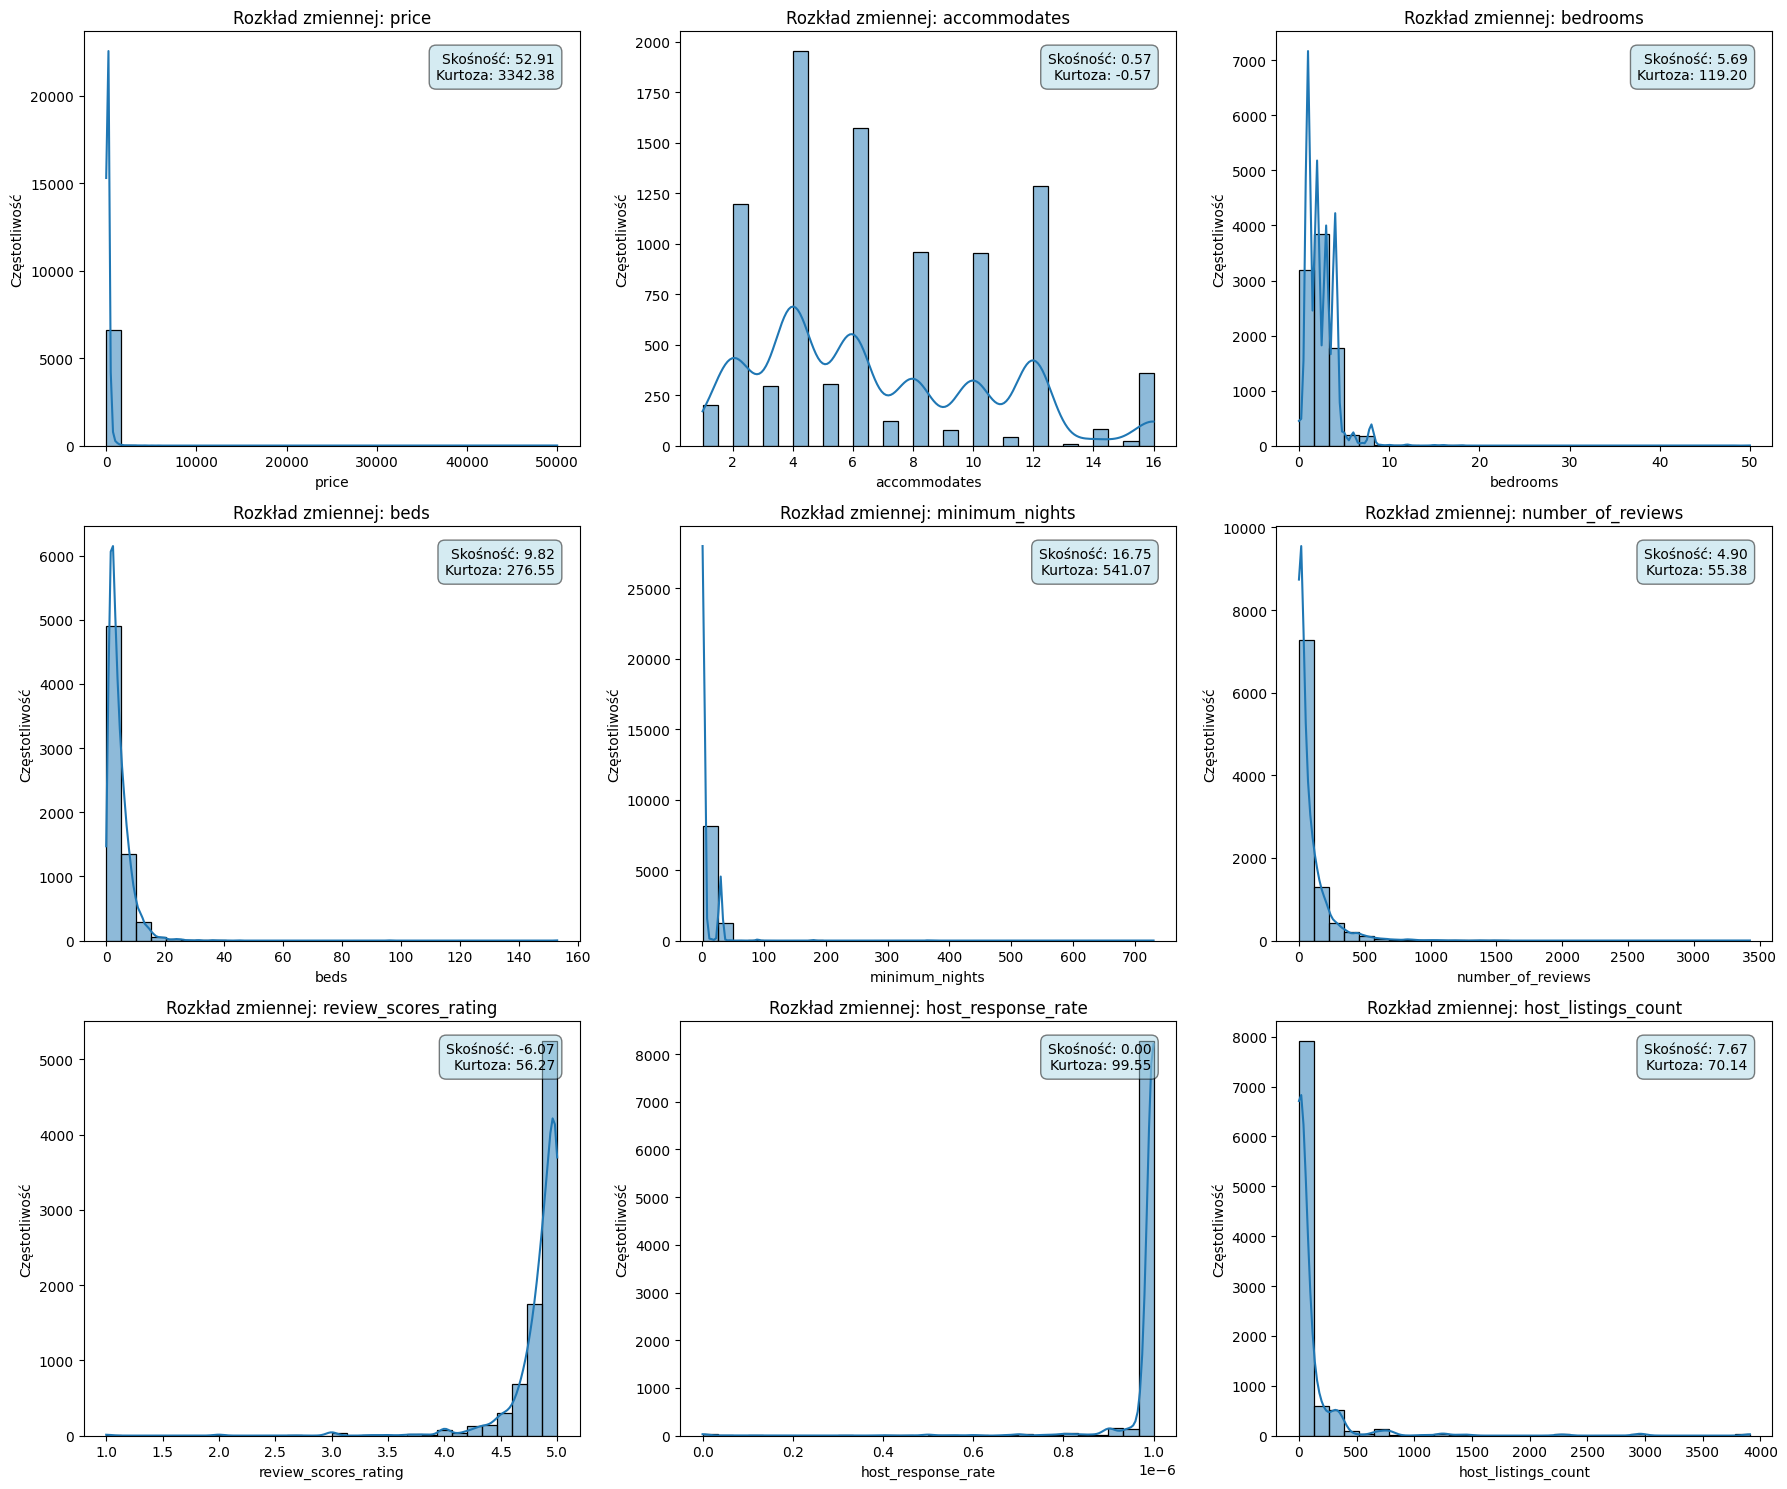

In [ ]:
print("Rozkłady dla wybranych zmiennych numerycznych:")

# Wybór zmiennych numerycznych do wizualizacji
selected_cols_numeric = [
    'price', 'accommodates', 'bedrooms', 'beds',
    'minimum_nights', 'number_of_reviews', 'review_scores_rating',
    'host_response_rate', 'host_listings_count'
]

plt.figure(figsize=(18, 15))
for index, column in enumerate(selected_cols_numeric):
    plt.subplot(3, 3, index + 1) # 3 wiersze, 3 kolumny dla wykresów - ułożenie
    sns.histplot(df[column].dropna(), kde=True, bins=30)
    plt.title(f'Rozkład zmiennej: {column}')
    plt.xlabel(column)
    plt.ylabel('Częstotliwość')

    # Skośność i kurtoza
    skewness = df[column].skew()
    kurtosis = df[column].kurt()
    plt.text(0.95, 0.95, f'Skośność: {skewness:.2f}\nKurtoza: {kurtosis:.2f}',
             transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

Obserwacje dotyczące rozkładów zmiennych numerycznych:

*   `price`: Rozkład jest prawoskośny, czyli większość ofert ma niższą cenę, a mało ofert ma bardzo wysokie ceny.
*   `accommodates`: Rozkład jest prawoskośny, ale umiarkowanie. Koncentracja na wykresie jest zauważona dla mniejszych wartości, ale i dla tych więjszych. (2, 4, 6, 12)
*   `bedrooms`, `beds`: Rozkłady prawoskośne, większość ofert ma mniej sypialni i łóżek. Wartości odstające również są na wykresie(bardzo duża liczba łóżek).
*   `minimum_nights`: Rozkład jest prawoskośny, czyli z dużą koncentracją na mniejszej ilości nocy, ale z długim "ogonem" w prawo, wskazującym na istnienie ofert z dłuższymi minimalnymi pobytami.
*   `number_of_reviews`: Rozkład jest prawoskośny, czyli większość ofert ma stosunkowo mało recenzji, ale są też oferty z bardzo dużą liczbą recenzji.
*   `review_scores_rating`: Rozkład jest lewoskośny, czyli większość ofert ma wysokie oceny.
*   `host_response_rate`: Rozkład jest lewoskośny, czyli dużo ofert ma bardzo wysoką liczbę odpowiedzi. Rozkład ma silną koncentrację blisko 1.0.
*   `host_listings_count`: Rozkład jest prawoskośny, czyli większość gospodarzy ma tylko kilka ofert. Mała ilość gospodarzy posiada dużo ofert.

Wiele zmiennych ma prawą skośność.

Rozkłady dla wybranych zmiennych kategorycznych:


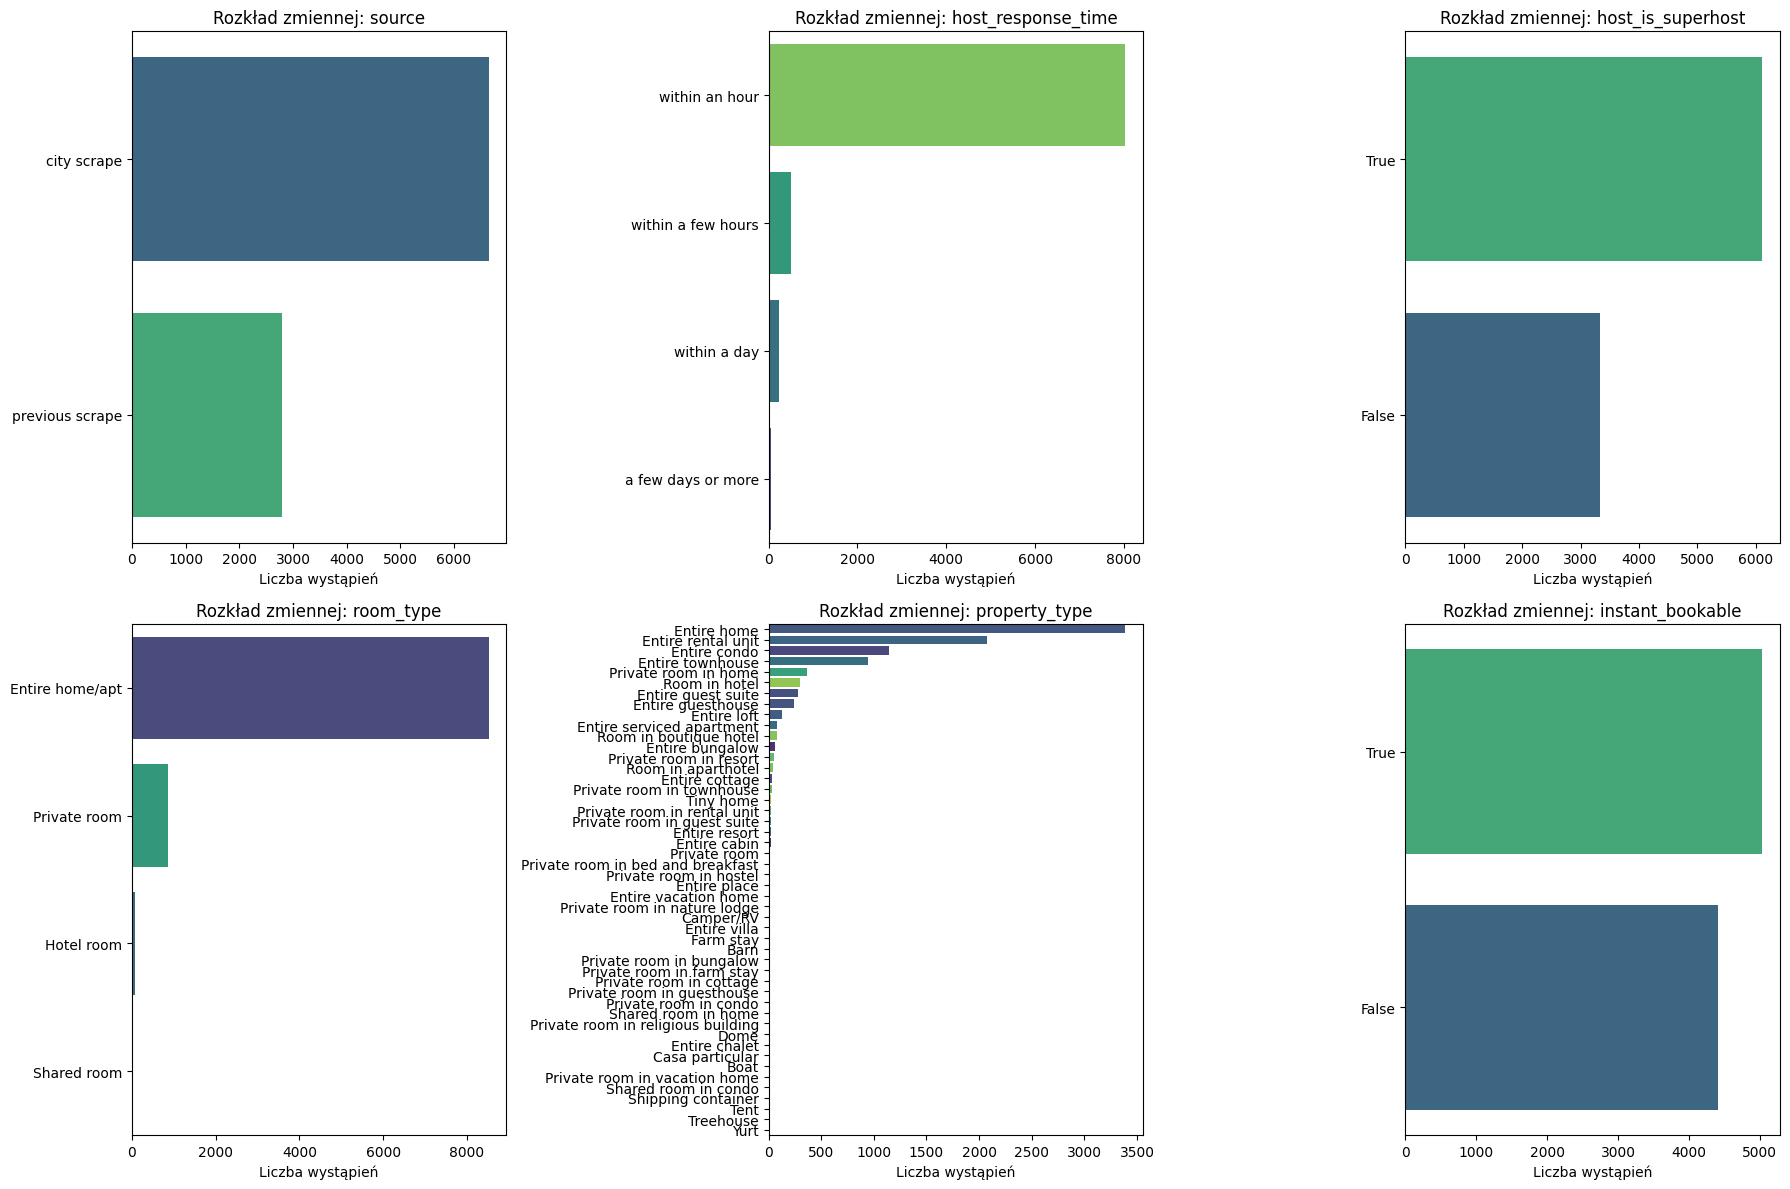

In [ ]:
print("Rozkłady dla wybranych zmiennych kategorycznych:")

# Wybieramy zmienne kategoryczne do wizualizacji
selected_cols_categorical = [
    'source', 'host_response_time', 'host_is_superhost',
    'room_type', 'property_type', 'instant_bookable'
]

plt.figure(figsize=(18, 12))
for i, col in enumerate(selected_cols_categorical):
    plt.subplot(2, 3, i + 1) # 2 wiersze, 3 kolumny
    sns.countplot(y=col, data=df, order=df[col].value_counts().index, hue=col, palette='viridis', legend=False)
    plt.title(f'Rozkład zmiennej: {col}')
    plt.xlabel('Liczba wystąpień')
    plt.ylabel('')

plt.tight_layout()
plt.show()

Obserwacje dotyczące rozkładów zmiennych kategorycznych:

*   `source`: Większość danych pochodzi z jednego źródła (city scrape).
*   `host_response_time`: Najczęściej gospodarze odpowiadają "within an hour", co wskazuje na dobry czas odpowiedzi.
*   `host_is_superhost`: Więcej niż połowa gospodarzy to "superhost".
*   `room_type`: Najpopularniejsze typy pokoi to "Entire home/apt",a następnie "Private room".
*   `property_type`: Istnieje duża różnorodność typów nieruchomości, ale najwięcej jest "Entire rental unit", "Entire condo" oraz "Entire home".
*   `instant_bookable`: Ponad połowa ofert jest dostępna do natychmiastowej rezerwacji.


##10. Czyszczenie danych

Plan czyszczenia danych:
1. Usunę kolumny, które mają dużą ilość brakujących danych - usunę 'neighbourhood_group_cleansed', 'calendar_updated', oraz 'license', ponieważ zawierają odpowiednio 100%, 100%, oraz 89% brakujących wartości.

2. Uzupełnię brakujące dane numeryczne:
Uzupełnię braki w kolumnach wartością mediany. Kolumnę 'reviews_per_month' uzupełnię wartością 0, ponieważ skoro nie ma danych w takiej kolumnie, to wnioskuję, że recenzja jeszcze się nie pojawiła
3. Uzupełnię brakujące dane kategoryczne i tekstowe:
Uzupełnię braki w kolumnach wartością najczęściej występującą. Kolumny z tekstem, takie jak 'description' oznaczę jako brak danych.
4. Uzupełnię brakujące dane z datą:
Zamiast 'first_review' i 'last_review' stworzę bardziej informatywną cechę pochodną
5. Obsłużenie wartoci odstających:
Dla kolumn 'price' i 'beds' przytnę wartości skrajne.
Skrajnie wysokie wartości (2.147e+09) w kolumnach dotyczących minimalnych i maksymalnych długości pobytu (np. 'minimum_maximum_nights', 'maximum_maximum_nights') zamienię na bardziej realistyczny limit (np. 365 dni) lub na 'np.inf' jeśli oznaczają brak limitu.
6. Normalizacja danych


In [ ]:
columns_to_delete = ['neighbourhood_group_cleansed', 'calendar_updated', 'license']
df.drop(columns=columns_to_delete, inplace=True)

print(f"Zaktualizowana liczba kolumn w DataFrame: {df.shape[1]}")

Zaktualizowana liczba kolumn w DataFrame: 76


In [ ]:
# Obliczanie liczby brakujących wartości dla każdej kolumny
missing_values = df.isnull().sum()

# Obliczanie procentu brakujących wartości dla każdej kolumny
missing_values_percent = (df.isnull().sum() / len(df)) * 100

# Tworzenie DataFrame z brakującymi wartościami
missing_info = pd.DataFrame({
    'Missing Values Count': missing_values,
    'Missing Values Percent': missing_values_percent
})

# Filtrowanie i sortowanie kolumn, które mają brakujące wartości
missing_info = missing_info[missing_info['Missing Values Count'] > 0].sort_values(by='Missing Values Count', ascending=False)

print("\nBrakujące dane po usunięciu kolumn z dużą liczbą braków:")
display(missing_info)


Brakujące dane po usunięciu kolumn z dużą liczbą braków:


,Missing Values Count,Missing Values Percent
neighborhood_overview,3486,36.916234
neighbourhood,3486,36.916234
price,2809,29.746902
estimated_revenue_l365d,2809,29.746902
host_about,2805,29.704543
bathrooms,2801,29.662184
beds,2801,29.662184
host_location,2045,21.656253
host_neighbourhood,1414,14.974055
review_scores_value,994,10.526316


In [ ]:
# Kolumny numeryczne do uzupełnienia medianą
median_cols = [
    'price', 'estimated_revenue_l365d', 'bathrooms', 'bedrooms', 'beds',
    'host_response_rate', 'host_listings_count', 'host_total_listings_count',
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
    'review_scores_value'
]

for column in median_cols:
    if column in df.columns:
        median_value = df[column].median()
        df[column] = df[column].fillna(median_value)
        print(f"Uzupełniono braki w kolumnie '{column}' medianą: {median_value}")

# Kolumna 'reviews_per_month' do uzupełnienia wartością 0
if 'reviews_per_month' in df.columns:
    df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
    print(f"Uzupełniono braki w kolumnie 'reviews_per_month' wartością 0")

# Sprawdzenie, czy po uzupełnieniu wartości brakujące zniknęły
print("\nSprawdzenie brakujących wartości w uzupełnionych kolumnach:")
missing_values_after_ = df[median_cols + ['reviews_per_month']].isnull().sum()
print(missing_values_after_[missing_values_after_ > 0])

print("Numeryczne kolumny zostały uzupełnione.")

Uzupełniono braki w kolumnie 'price' medianą: 158.0
Uzupełniono braki w kolumnie 'estimated_revenue_l365d' medianą: 17634.0
Uzupełniono braki w kolumnie 'bathrooms' medianą: 2.0
Uzupełniono braki w kolumnie 'bedrooms' medianą: 2.0
Uzupełniono braki w kolumnie 'beds' medianą: 3.0
Uzupełniono braki w kolumnie 'host_response_rate' medianą: 1e-06
Uzupełniono braki w kolumnie 'host_listings_count' medianą: 9.0
Uzupełniono braki w kolumnie 'host_total_listings_count' medianą: 12.0
Uzupełniono braki w kolumnie 'review_scores_rating' medianą: 4.91
Uzupełniono braki w kolumnie 'review_scores_accuracy' medianą: 4.93
Uzupełniono braki w kolumnie 'review_scores_cleanliness' medianą: 4.89
Uzupełniono braki w kolumnie 'review_scores_checkin' medianą: 4.95
Uzupełniono braki w kolumnie 'review_scores_communication' medianą: 4.97
Uzupełniono braki w kolumnie 'review_scores_location' medianą: 4.86
Uzupełniono braki w kolumnie 'review_scores_value' medianą: 4.83
Uzupełniono braki w kolumnie 'reviews_per_

In [ ]:
mode_cols = [
    'host_response_time', 'host_acceptance_rate', 'host_is_superhost',
    'host_has_profile_pic', 'host_identity_verified', 'has_availability',
    'instant_bookable', 'host_name', 'host_location', 'host_neighbourhood',
    'host_verifications'
]

for column in mode_cols:
    if column in df.columns:
        mode_value = None
        if not df[column].mode().empty:
            mode_value = df[column].mode()[0]
        else:
            mode_value = np.nan

        if pd.isna(mode_value) and df[column].dtype == 'bool': #Moda dla boolean
            mode_value = False
        df[column] = df[column].fillna(mode_value)
        print(f"Uzupełniono braki w kolumnie '{column}' modą: {mode_value}")

# Kolumny tekstowe do uzupełnienia wartością 'Brak danych'
text_cols = ['description', 'neighborhood_overview', 'host_about', 'neighbourhood']

for column in text_cols:
    if column in df.columns:
        df[column] = df[column].fillna('Brak danych')
        print(f"Uzupełniono braki w kolumnie '{column}' wartością 'Brak danych'")

# Sprawdzenie, czy po uzupełnieniu wartości brakujące zniknęły
print("\nSprawdzenie brakujących wartości w uzupełnionych kolumnach:")
missing_after = df[mode_cols + text_cols].isnull().sum()
print(missing_after[missing_after > 0])

print("Kategoryczne kolumny zostały uzupełnione.")

Uzupełniono braki w kolumnie 'host_response_time' modą: within an hour
Uzupełniono braki w kolumnie 'host_acceptance_rate' modą: 100%
Uzupełniono braki w kolumnie 'host_is_superhost' modą: True
Uzupełniono braki w kolumnie 'host_has_profile_pic' modą: True
Uzupełniono braki w kolumnie 'host_identity_verified' modą: True
Uzupełniono braki w kolumnie 'has_availability' modą: True
Uzupełniono braki w kolumnie 'instant_bookable' modą: True
Uzupełniono braki w kolumnie 'host_name' modą: AvantStay Nashville
Uzupełniono braki w kolumnie 'host_location' modą: Nashville, TN
Uzupełniono braki w kolumnie 'host_neighbourhood' modą: Downtown
Uzupełniono braki w kolumnie 'host_verifications' modą: ['email', 'phone']
Uzupełniono braki w kolumnie 'description' wartością 'Brak danych'
Uzupełniono braki w kolumnie 'neighborhood_overview' wartością 'Brak danych'
Uzupełniono braki w kolumnie 'host_about' wartością 'Brak danych'
Uzupełniono braki w kolumnie 'neighbourhood' wartością 'Brak danych'

Sprawdze

In [ ]:
if 'first_review' in df.columns and 'last_review' in df.columns:
    # Obliczamy dni of pierwszej recenzji
    df['days_since_first_review'] = (df['last_scraped'] - df['first_review']).dt.days

    # Liczymy dni od ostatnie recenzji
    df['days_since_last_review'] = (df['last_scraped'] - df['last_review']).dt.days

    print("Nowe zmienne 'days_since_first_review' i 'days_since_last_review' zostały utworzone.")

    # Usuwamy oryginalne kolumny 'first_review' i 'last_review'
    columns_to_delete_dates = ['first_review', 'last_review']
    df.drop(columns=columns_to_delete_dates, inplace=True)

    print(f"Kolumny {columns_to_delete_dates} zostały usunięte.")

    # Sprawdzenie brakujących wartości w nowo utworzonych kolumnach
    print("\nSprawdzenie brakujących wartości w nowo utworzonych kolumnach:")
    missing_counts = df[['days_since_first_review', 'days_since_last_review']].isnull().sum()
    missing_percentages = (missing_counts / len(df)) * 100
    missing_info = pd.DataFrame({
        'Missing Values Count': missing_counts,
        'Missing Values Percent': missing_percentages
    })
    display(missing_info)

else:
    print("Kolumny 'first_review' i/lub 'last_review' nie znaleziono.")

    if 'days_since_first_review' in df.columns and 'days_since_last_review' in df.columns:
        print("'days_since_first_review' i 'days_since_last_review' już istnieją.")
        print("\nSprawdzenie brakujących wartości w nowych kolumnach:")
        missing_counts = df[['days_since_first_review', 'days_since_last_review']].isnull().sum()
        missing_percentages = (missing_counts / len(df)) * 100
        missing_info = pd.DataFrame({
            'Missing Values Count': missing_counts,
            'Missing Values Percent': missing_percentages
        })
        display(missing_info)
    else:
        print("Żadne kolumny nie zostały znalezione.")

Kolumny 'first_review' i/lub 'last_review' nie znaleziono.
'days_since_first_review' i 'days_since_last_review' już istnieją.

Sprawdzenie brakujących wartości w nowych kolumnach:


,Missing Values Count,Missing Values Percent
days_since_first_review,994,10.526316
days_since_last_review,994,10.526316


In [ ]:
#Uzupełnienie brakujących wartości medianą
median_days_since_first_review = df['days_since_first_review'].median()
median_days_since_last_review = df['days_since_last_review'].median()

df['days_since_first_review'] = df['days_since_first_review'].fillna(median_days_since_first_review)
df['days_since_last_review'] = df['days_since_last_review'].fillna(median_days_since_last_review)

print(f"Uzupełniono braki w 'days_since_first_review' medianą: {median_days_since_first_review}")
print(f"Uzupełniono braki w 'days_since_last_review' medianą: {median_days_since_last_review}")

print("\nSprawdzenie brakujących wartości po uzupełnieniu:")
print(df[['days_since_first_review', 'days_since_last_review']].isnull().sum())

Uzupełniono braki w 'days_since_first_review' medianą: 948.0
Uzupełniono braki w 'days_since_last_review' medianą: 23.0

Sprawdzenie brakujących wartości po uzupełnieniu:
days_since_first_review    0
days_since_last_review     0
dtype: int64


In [ ]:
# Obsługa wartości odstających dla 'price' i 'beds'
for column in ['price', 'beds']:
    if column in df.columns:
        upper_bound = df[column].quantile(0.99)
        df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
        print(f"Wartości w kolumnie '{column}' powyżej {upper_bound:.2f} zostały ograniczone do tej wartości.")

# Obsługa 0.0 w 'price'
# 0.0 może być błędem i zastępujemy je medianą
if 'price' in df.columns:
    median_price = df['price'].median()
    df['price'] = np.where(df['price'] == 0.0, median_price, df['price'])
    print(f"Wartości 0.0 w kolumnie 'price' zostały zastąpione medianą: {median_price:.2f}.")

# Obsługa wysokich wartości w kolumnach długości pobytu
nights_cols = [
    'minimum_maximum_nights',
    'maximum_maximum_nights',
    'maximum_nights_avg_ntm'
]

for column in nights_cols:
    if column in df.columns:
        df[column] = np.where(df[column] > 365, 365, df[column])
        print(f"Skrajnie wysokie wartości w kolumnie '{column}' zostały ograniczone do 365.")

print("Obsługa wartości odstających została zakończona.")

Wartości w kolumnie 'price' powyżej 865.39 zostały ograniczone do tej wartości.
Wartości w kolumnie 'beds' powyżej 16.00 zostały ograniczone do tej wartości.
Wartości 0.0 w kolumnie 'price' zostały zastąpione medianą: 158.00.
Skrajnie wysokie wartości w kolumnie 'minimum_maximum_nights' zostały ograniczone do 365.
Skrajnie wysokie wartości w kolumnie 'maximum_maximum_nights' zostały ograniczone do 365.
Skrajnie wysokie wartości w kolumnie 'maximum_nights_avg_ntm' zostały ograniczone do 365.
Obsługa wartości odstających została zakończona.


In [ ]:
missing_values = df.isnull().sum()

missing_values_percent = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Values Count': missing_values,
    'Missing Values Percent': missing_values_percent
})

missing_info = missing_info[missing_info['Missing Values Count'] > 0].sort_values(by='Missing Values Count', ascending=False)

print("\nBrakujące dane po uzupełnieniu kolumn:")
display(missing_info)


Brakujące dane po uzupełnieniu kolumn:


,Missing Values Count,Missing Values Percent
bathrooms_text,13,0.137668
host_since,11,0.116488
host_thumbnail_url,11,0.116488
host_picture_url,11,0.116488
minimum_minimum_nights,10,0.105899
maximum_minimum_nights,10,0.105899
minimum_maximum_nights,10,0.105899
maximum_maximum_nights,10,0.105899


**Normalizacja danych numerycznych - Z-score**

In [ ]:
# Lista kolumn numerycznych do standaryzacji
columns_standardize = [
    'accommodates', 'bathrooms', 'bedrooms', 'beds', 'price',
    'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights',
    'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',
    'availability_30', 'availability_60', 'availability_90', 'availability_365',
    'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'availability_eoy',
    'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d',
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms',
    'reviews_per_month', 'days_since_first_review', 'days_since_last_review',
    'host_listings_count', 'host_total_listings_count'
]

# Filtrujemy kolumny, aby upewnić się, że istnieją i są numeryczne (int/float)
actual_columns_to_standardize = [
    column for column in columns_standardize
    if column in df.columns and pd.api.types.is_numeric_dtype(df[column])
]

# Inicjalizacja Scalera
scaler = StandardScaler()

# Dopasowanie i transformacja danych
df[actual_columns_to_standardize] = scaler.fit_transform(df[actual_columns_to_standardize])

print("Wybrane kolumny numeryczne zostały poddane standaryzacji Z-score.")
print("\nDane po standaryzacji (pierwsze 5 wierszy):")
display(df[actual_columns_to_standardize].head())

Wybrane kolumny numeryczne zostały poddane standaryzacji Z-score.

Dane po standaryzacji (pierwsze 5 wierszy):


,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,...,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,days_since_first_review,days_since_last_review,host_listings_count,host_total_listings_count
0,-1.510577,-0.86213,-0.834333,-1.015364,-1.161203,1.452771,-0.212485,1.454550,0.912325,0.528780,...,0.698039,-0.554613,-0.544663,-0.075719,-0.049413,0.559762,4.981724,7.165818,-0.296933,-0.285752
1,-1.250738,-0.86213,-0.834333,-1.015364,-0.944928,-0.319758,-1.117408,-0.302348,-0.322036,-2.077133,...,0.494259,-0.554613,-0.544663,-0.075719,-0.049413,1.383282,2.177841,-0.370363,-0.296933,-0.284038
2,-1.250738,-0.86213,-0.250083,-0.658372,-0.776714,-0.258636,-1.117408,-0.241766,-0.279471,0.528780,...,0.426332,-0.554613,-0.524086,-0.228044,-0.049413,1.020933,4.180615,-0.388989,-0.296933,-0.285752
3,-1.250738,-0.86213,-0.834333,-0.658372,-1.233294,1.452771,-0.212485,1.454550,0.912325,0.528780,...,-0.151046,-0.411962,-0.544663,0.838231,20.237718,-0.576696,3.987100,1.972819,-0.246064,-0.244622
4,-1.510577,-0.86213,-0.250083,-0.658372,-1.241304,1.452771,-0.212485,1.454550,0.912325,0.528780,...,-0.286900,-0.411962,-0.544663,0.838231,20.237718,-0.630225,3.971494,8.719248,-0.246064,-0.244622


##11. Zależności między zmiennymi

In [ ]:
numeric_columns_all = df.select_dtypes(include=[np.number]).columns.tolist()

exclude_from = ['id', 'scrape_id', 'host_id', 'latitude', 'longitude']

exclude_from = [column for column in exclude_from if column in df.columns]

numerical_columns_corr = [column for column in numeric_columns_all if column not in exclude_from]

print(f"Number of numerical variables for correlation analysis: {len(numerical_columns_corr)}")
print("Numerical columns for correlation analysis:")
for column in numerical_columns_corr:
    print(column)

Number of numerical variables for correlation analysis: 41
Numerical columns for correlation analysis:
host_response_rate
host_listings_count
host_total_listings_count
accommodates
bathrooms
bedrooms
beds
price
minimum_nights
maximum_nights
minimum_minimum_nights
maximum_minimum_nights
minimum_maximum_nights
maximum_maximum_nights
minimum_nights_avg_ntm
maximum_nights_avg_ntm
availability_30
availability_60
availability_90
availability_365
number_of_reviews
number_of_reviews_ltm
number_of_reviews_l30d
availability_eoy
number_of_reviews_ly
estimated_occupancy_l365d
estimated_revenue_l365d
review_scores_rating
review_scores_accuracy
review_scores_cleanliness
review_scores_checkin
review_scores_communication
review_scores_location
review_scores_value
calculated_host_listings_count
calculated_host_listings_count_entire_homes
calculated_host_listings_count_private_rooms
calculated_host_listings_count_shared_rooms
reviews_per_month
days_since_first_review
days_since_last_review


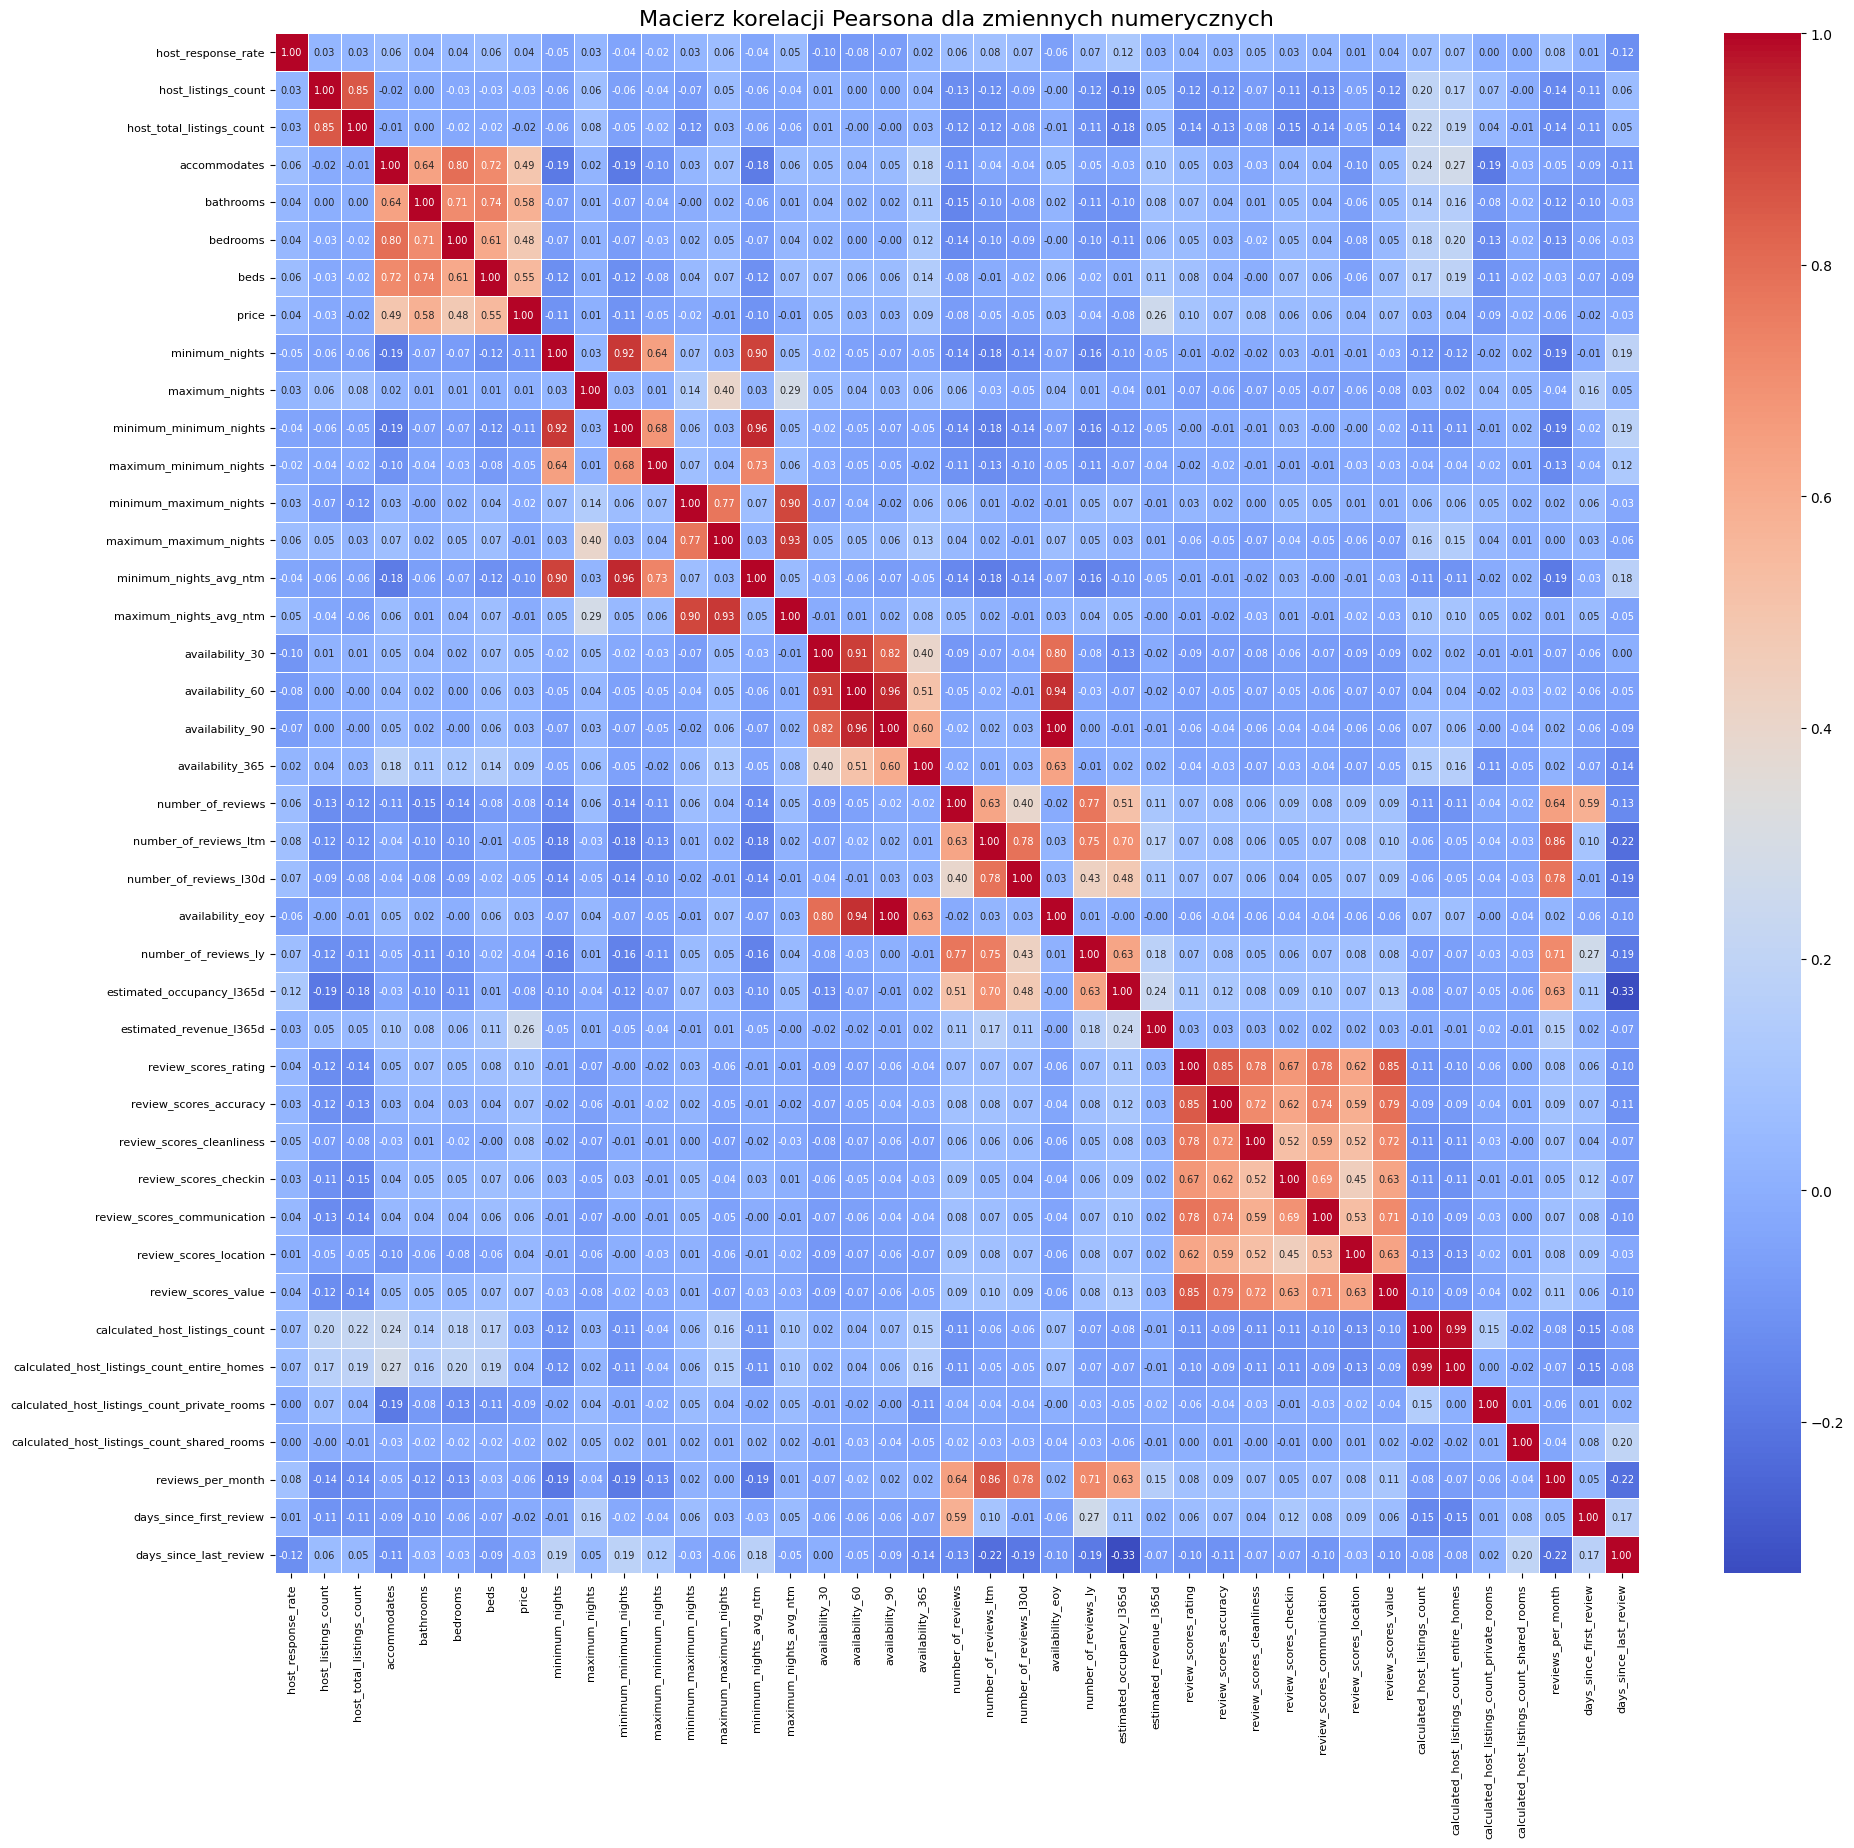

Pearson correlation matrix calculated and visualized successfully.


In [ ]:
#Calculating the Pearson correlation matrix
correlation_matrix = df[numerical_columns_corr].corr(method='pearson')

#Heeatmap
plt.figure(figsize=(22, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 7})
plt.title('Macierz korelacji Pearsona dla zmiennych numerycznych', fontsize=16)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

print("Pearson correlation matrix calculated and visualized successfully.")


Analiza wybranych zależności za pomocą wykresów punktowych...


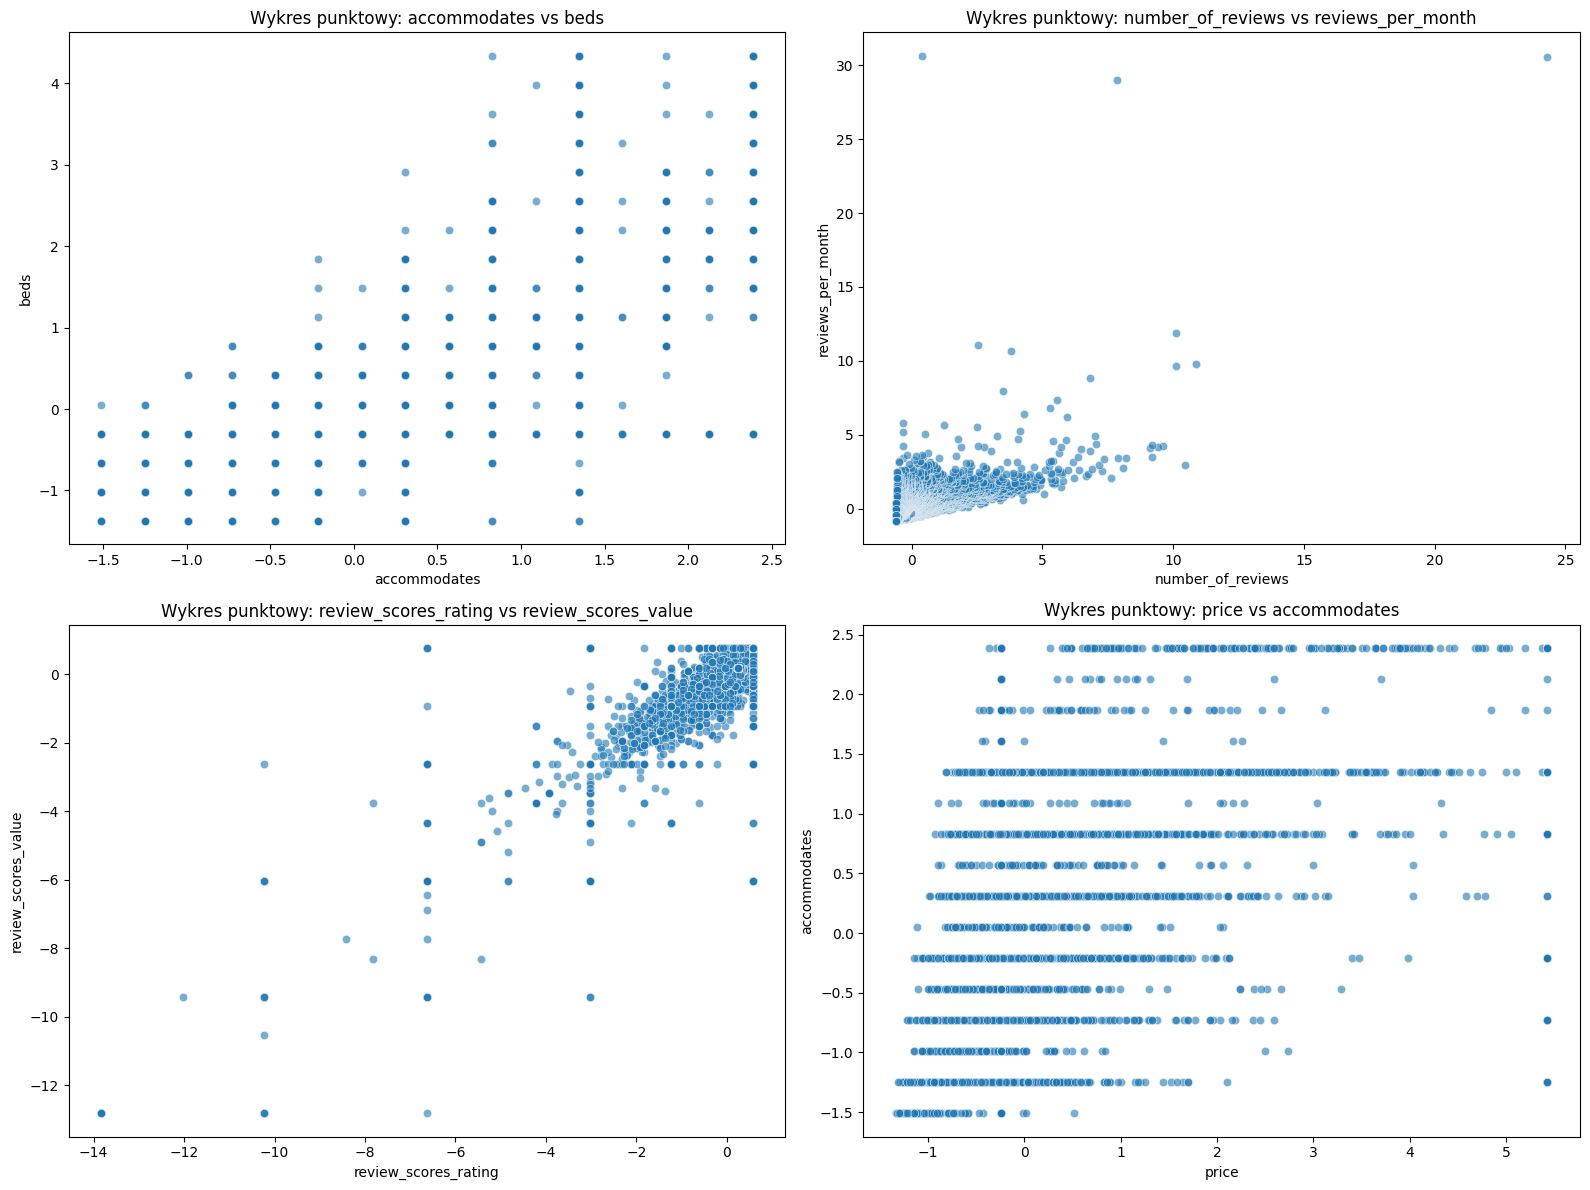

Scatter plots for selected numerical pairs generated successfully.


In [ ]:
numerical_pairs_scatter = [
    ('accommodates', 'beds'),
    ('number_of_reviews', 'reviews_per_month'),
    ('review_scores_rating', 'review_scores_value'),
    ('price', 'accommodates')
]

print("\nAnaliza wybranych zależności za pomocą wykresów punktowych...")

plt.figure(figsize=(16, 12))
for i, (column1, column2) in enumerate(numerical_pairs_scatter):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(data=df, x=column1, y=column2, alpha=0.6)
    plt.title(f'Wykres punktowy: {column1} vs {column2}')
    plt.xlabel(column1)
    plt.ylabel(column2)
plt.tight_layout()
plt.show()

print("Scatter plots for selected numerical pairs generated successfully.")

1. `accommodates` vs `beds`:
Tutaj mamy silną korelację dodatnią. Im więcej miejsc noclegowych, tym więcej łóżek.
2. `number_of_reviews` vs `reviews_per_month`:
Tutaj widać silną korelację dodatnią. Oferty z wysoką liczbą recenzji, zazwyczaj mają też więcej recenzji w skali miesiąca.
3. `reviews_scores_rating` vs `reviews_scores_value`:
Tutaj widać silną korelację dodatnią. Oferty ocenianie wysoko są również wysoko oceniane pod kątem stosunku jakości do ceny.
4. `price` vs `accommodates`:
Tutaj widać dodatnią korelację. Im więcej osób może zmieścić się w danym miejscu, tym wyższa cena.

In [ ]:
print("\nAnaliza zmiennych kategorycznych")

categorical_bool_columns = df.select_dtypes(include=['category', 'bool', 'object']).columns.tolist()

excluded_cramers = [
    'listing_url', 'name', 'description', 'neighborhood_overview', 'picture_url',
    'host_url', 'host_name', 'host_about', 'host_thumbnail_url', 'host_picture_url',
    'amenities', 'host_verifications', 'host_location', 'host_neighbourhood', 'neighbourhood',
    'last_scraped', 'host_since', 'calendar_last_scraped'
]

categorical_cols_cramers = []
max_unique_categories = 30

for column in categorical_bool_columns:
    if column not in excluded_cramers:
        num_unique = df[column].nunique()
        if df[column].dtype == 'bool':
            categorical_cols_cramers.append(column)
        elif num_unique > 1 and num_unique <= max_unique_categories:
            categorical_cols_cramers.append(column)

print(f"Liczba zmiennych kategorycznych do analizy Cramera V: {len(categorical_cols_cramers)}")
print("Zmienne kategoryczne dla analizy Cramera V:")
for col in categorical_cols_cramers:
    print(col)


Analiza zmiennych kategorycznych
Liczba zmiennych kategorycznych do analizy Cramera V: 8
Zmienne kategoryczne dla analizy Cramera V:
source
host_response_time
host_is_superhost
host_has_profile_pic
host_identity_verified
room_type
has_availability
instant_bookable



Macierz skojarzeń Cramera V dla zmiennych kategorycznych:


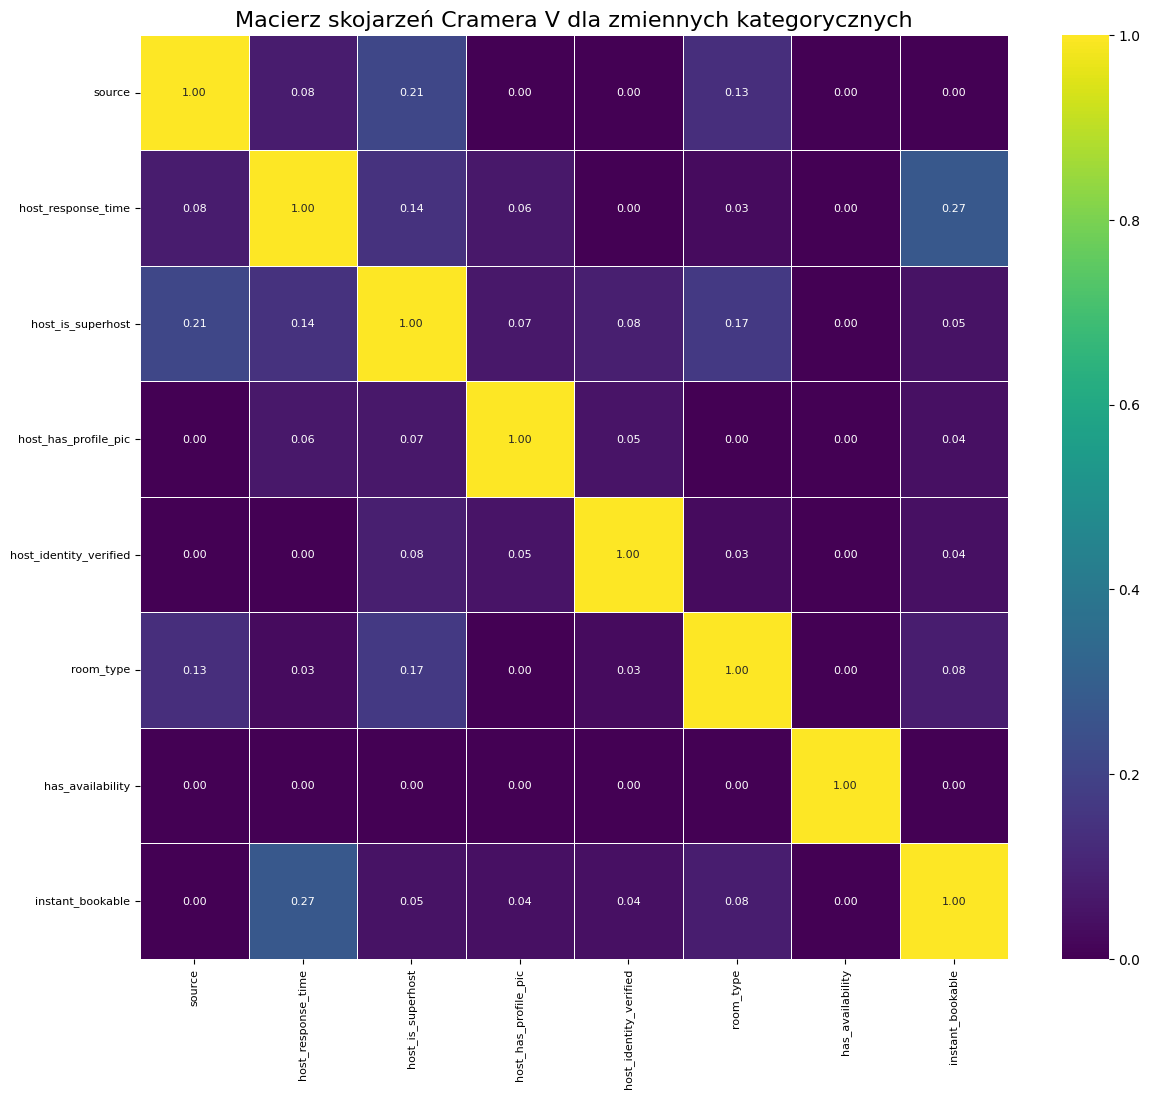

Cramer's V matrix calculated and visualized successfully.


In [ ]:
#Funkcja licząca Cramer V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if min(kcorr, rcorr) == 0:
        return 0
    return np.sqrt(phi2corr / min( (kcorr-1), (rcorr-1)))

#Cramer's V matrix
cramers_matrix = pd.DataFrame(index=categorical_cols_cramers, columns=categorical_cols_cramers)

for column1 in categorical_cols_cramers:
    for column2 in categorical_cols_cramers:
        if column1 == column2:
            cramers_matrix.loc[column1, column2] = 1.0
        else:
            pair_df = df[[column1, column2]].dropna()
            cramers_matrix.loc[column1, column2] = cramers_v(pair_df[column1], pair_df[column2])

# Convert to float for heatmap
cramers_matrix = cramers_matrix.astype(float)

print("\nMacierz skojarzeń Cramera V dla zmiennych kategorycznych:")
plt.figure(figsize=(14, 12))
sns.heatmap(cramers_matrix, annot=True, cmap='viridis', fmt=".2f", linewidths=.5, annot_kws={"size": 8})
plt.title("Macierz skojarzeń Cramera V dla zmiennych kategorycznych", fontsize=16)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

print("Cramer's V matrix calculated and visualized successfully.")


Analiza zależności między zmiennymi kategorycznymi a numerycznymi


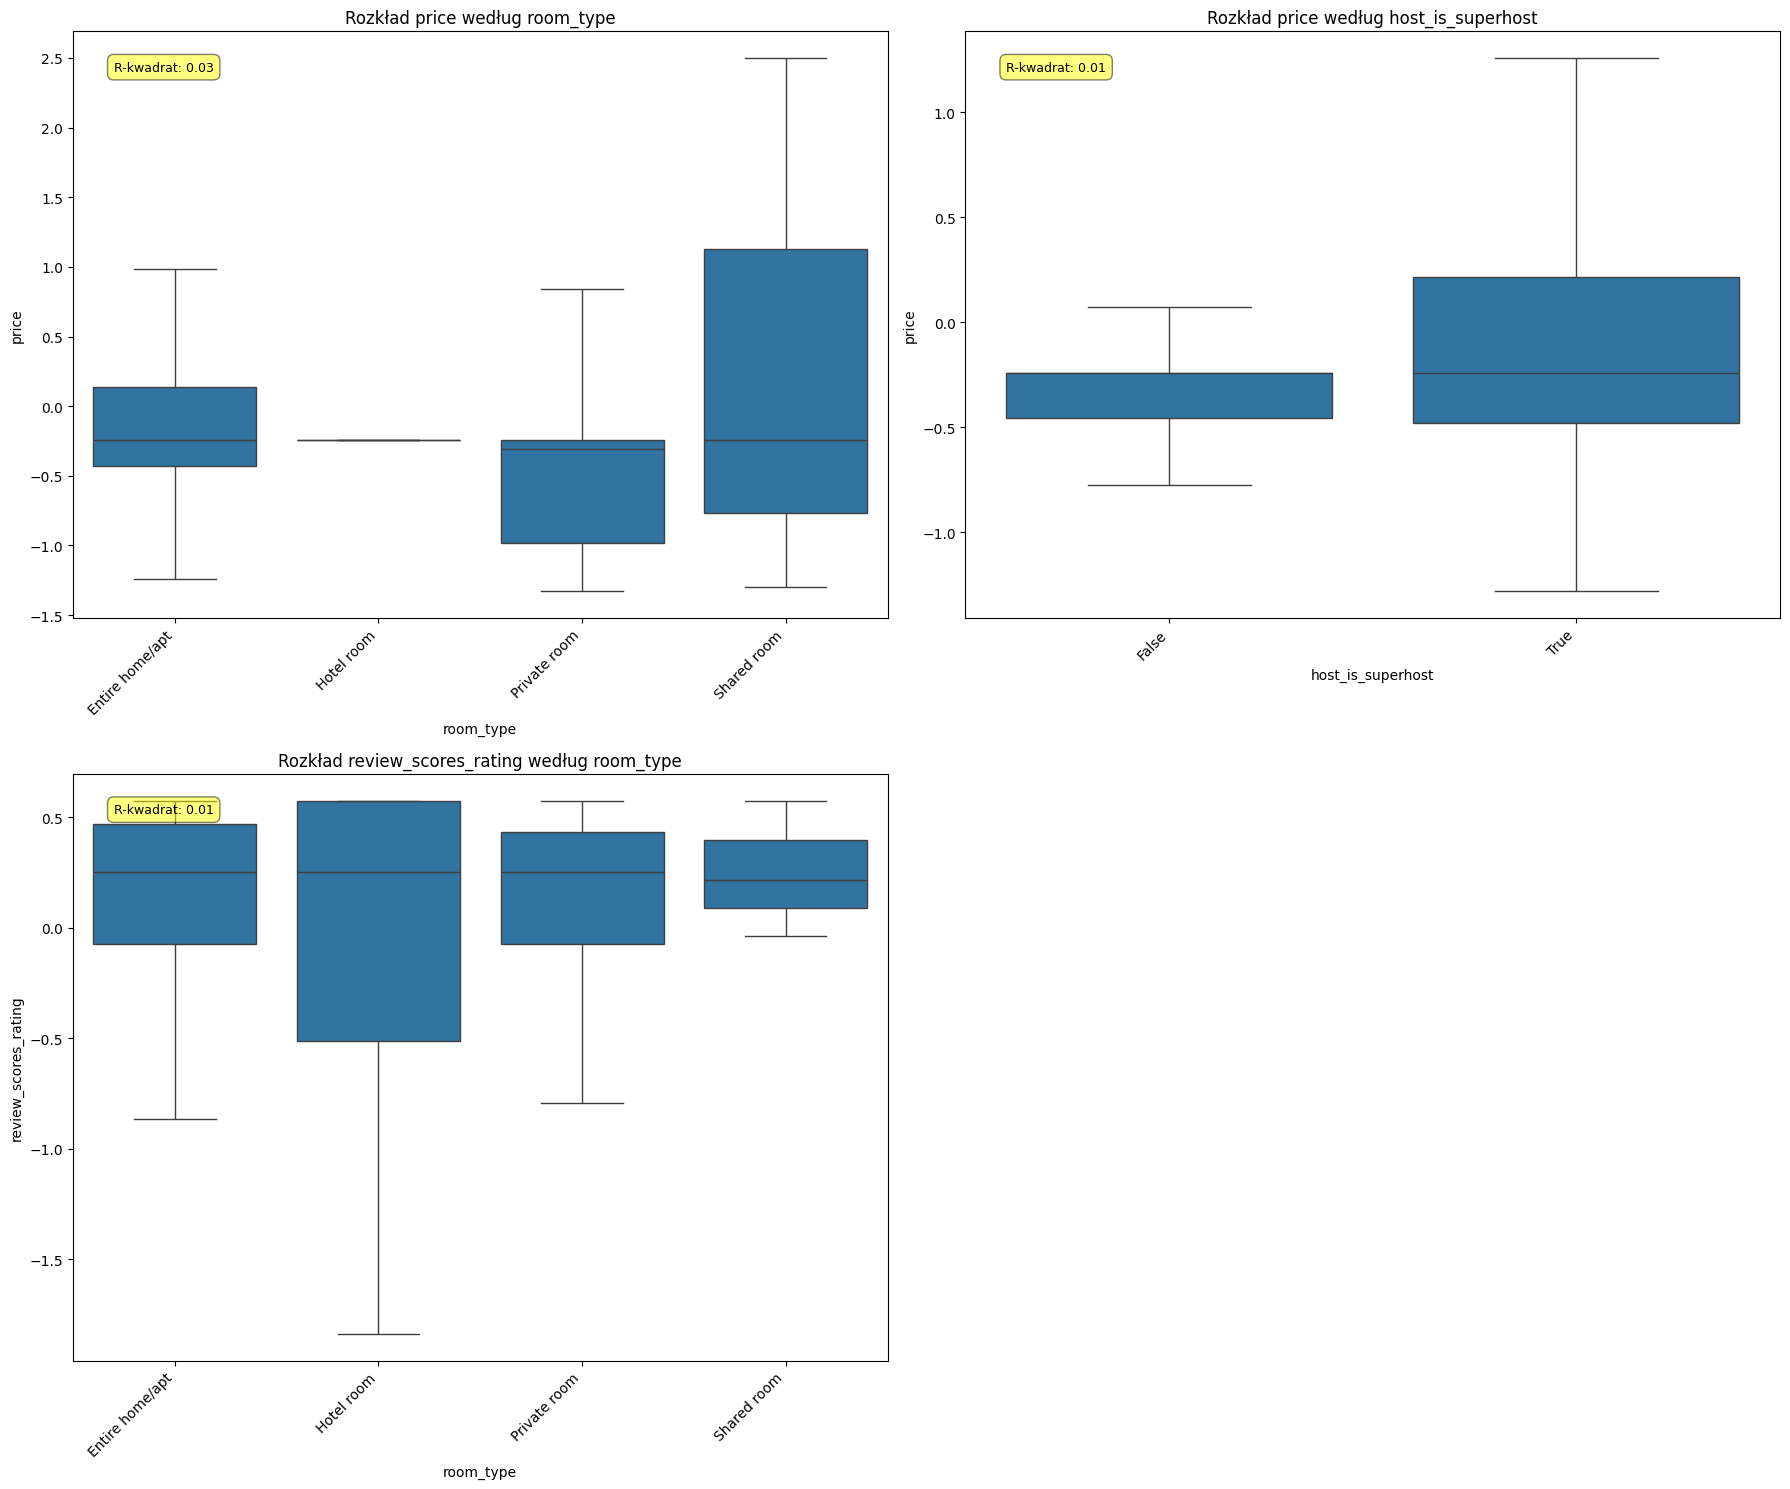


Analiza zależności między zmiennymi zakończona.


In [ ]:
print("\nAnaliza zależności między zmiennymi kategorycznymi a numerycznymi")

categorical_numerical_pairs = [
    ('room_type', 'price'),
    ('host_is_superhost', 'price'),
    ('room_type', 'review_scores_rating')
]

plt.figure(figsize=(18, 15))
for i, (cat_column, num_column) in enumerate(categorical_numerical_pairs):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df, x=cat_column, y=num_column, showfliers=False)
    plt.title(f'Rozkład {num_column} według {cat_column}')
    plt.xlabel(cat_column)
    plt.ylabel(num_column)
    plt.xticks(rotation=45, ha='right')

    pair_df = df[[cat_column, num_column]].dropna()
    if not pair_df.empty and pair_df[cat_column].nunique() > 1:
        model = smf.ols(f'{num_column} ~ C({cat_column})', data=pair_df).fit()
        r_squared = model.rsquared
        plt.text(0.05, 0.95, f'R-kwadrat: {r_squared:.2f}',
                 transform=plt.gca().transAxes, fontsize=9, verticalalignment='top',
                 bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))
    else:
        plt.text(0.05, 0.95, 'Model liniowy nie przeprowadzony (brak danych lub mniej niż 2 kategorie)',
                 transform=plt.gca().transAxes, fontsize=9, verticalalignment='top',
                 bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nAnaliza zależności między zmiennymi zakończona.")